In [1]:
import numpy as np

In [1]:
print('🧙🏻‍♂️')

🧙🏻‍♂️


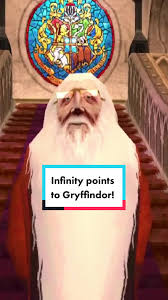

In [3]:
from IPython.display import Image, display
img = Image('./img.png')
display(img)

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. You do not need to change anything here, just read the comments.

In [2]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    Moreover, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        input_grad = module.backward(input, output_grad)
    """
    def __init__ (self):
        self._output = None
        self._input_grad = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        self._output = self._compute_output(input)
        return self._output

    def backward(self, input, output_grad):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self._input_grad = self._compute_input_grad(input, output_grad)
        self._update_parameters_grad(input, output_grad)
        return self._input_grad


    def _compute_output(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which will be stored in the `_output` field.

        Example: in case of identity operation:

        output = input
        return output
        """
        raise NotImplementedError


    def _compute_input_grad(self, input, output_grad):
        """
        Returns the gradient of the module with respect to its own input.
        The shape of the returned value is always the same as the shape of `input`.

        Example: in case of identity operation:
        input_grad = output_grad
        return input_grad
        """

        raise NotImplementedError

    def _update_parameters_grad(self, input, output_grad):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zero_grad(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def get_parameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def get_parameters_grad(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Layers

## 1. Batch normalization
One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ — mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [3]:
class BatchNormalization(Module):
    EPS = 1e-3

    def __init__(self, alpha=0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = 0.
        self.moving_variance = 1.

    def _compute_output(self, input):
        batch_mean = np.mean(input, axis=0)
        batch_variance = np.var(input, axis=0)
        if self.training:
          self.moving_mean = self.moving_mean * self.alpha + batch_mean * (1 - self.alpha)
          self.moving_variance = self.moving_variance * self.alpha + np.var(input, axis=0, ddof=1) * (1 - self.alpha)
          output = (input - batch_mean) / (batch_variance + self.EPS) ** 0.5
        else:
          output = (input - self.moving_mean) / (self.moving_variance + self.EPS) ** 0.5

        return output

    def _compute_input_grad(self, input, output_grad):
        N, num_features = input.shape
        
        # Step 1: Calculate mean and variance
        mu = np.mean(input, axis=0)
        var = np.var(input, axis=0)
        sigma = np.sqrt(var + self.EPS)
        
        # Step 2: grad_output w.r.t. normalized input (no scaling, so grad_hat_x = grad_output)
        grad_hat_x = output_grad  # No gamma scaling
        
        # Step 3: Calculate gradients of mean and variance
        grad_var = np.sum(grad_hat_x * (input - mu) * -0.5 * (var + self.EPS)**-1.5, axis=0)
        grad_mean = np.sum(grad_hat_x * -1 / sigma, axis=0) + grad_var * np.sum(-2 * (input - mu) / N, axis=0)
        
        # Step 4: Gradient w.r.t input
        grad_input = grad_hat_x / sigma + grad_var * 2 * (input - mu) / N + grad_mean / N
        
        return grad_input

    def __repr__(self):
        return "BatchNormalization"

In [4]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def _compute_output(self, input):
        output = input * self.gamma + self.beta
        return output

    def _compute_input_grad(self, input, output_grad):
        grad_input = output_grad * self.gamma
        return grad_input

    def _update_parameters_grad(self, input, output_grad):
        self.gradBeta = np.sum(output_grad, axis=0)
        self.gradGamma = np.sum(output_grad*input, axis=0)

    def zero_grad(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def get_parameters(self):
        return [self.gamma, self.beta]

    def get_parameters_grad(self):
        return [self.gradGamma, self.gradBeta]

    def __repr__(self):
        return "ChannelwiseScaling"

<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
C:\Users\danii\AppData\Local\Temp\ipykernel_8492\820473258.py:2: SyntaxWarning: invalid escape sequence '\g'
  """


Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

## 2. Dropout
Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [5]:
import scipy.stats as ss

class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = []

    def _compute_output(self, input):
        if self.training:
            self.mask = ss.bernoulli.rvs(1 - self.p, size=input.shape)
            output = input * self.mask / (1 - self.p)
        else:
            output = input
        return output

    def _compute_input_grad(self, input, output_grad):
        grad_input = output_grad / (1 - self.p) * self.mask
        return grad_input
        
    def __repr__(self):
        return "Dropout"

## 3. Conv2d

* input: `batch_size x in_channels x h x w`
* output: `batch_size x out_channels x h x w`

You should implement something like pytorch Conv2d layer with `stride=1` and zero-padding outside of image using `scipy.signal.correlate` function.

**Practical notes:**

* While the layer name is "convolution", the most of neural network frameworks (including tensorflow and pytorch) implement operation that is called [correlation](https://en.wikipedia.org/wiki/Cross-correlation#Cross-correlation_of_deterministic_signals) in signal processing theory. **So don't use** `scipy.signal.convolve` since it implements convolution in terms of signal processing.
* It may be convenient to use numpy.pad for zero-padding.
* It's rather ok to implement convolution over 4d array using 2 nested loops: one over batch size dimension and another one over output filters dimension

In [28]:
import scipy as sp
import scipy.signal
import skimage

class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super(Conv2d, self).__init__()
        assert kernel_size % 2 == 1, kernel_size

        stdv = 1./np.sqrt(in_channels)
        self.W = np.random.uniform(-stdv, stdv, size=(out_channels, in_channels, kernel_size, kernel_size))
        self.b = np.random.uniform(-stdv, stdv, size=(out_channels,))
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def _compute_output(self, input):
        pad_size = self.kernel_size // 2
        pad_input = np.pad(input, pad_width=((0, 0), (0, 0), (pad_size, pad_size), (pad_size, pad_size)))
        out = np.zeros((input.shape[0], self.out_channels, input.shape[2], input.shape[3]))
        for i in range(out.shape[0]):
            for j in range(out.shape[1]):
                out[i, j] = sp.signal.correlate(pad_input[i], self.W[j], mode='valid') + self.b[j]

        self._output = out

        return self._output

    def _compute_input_grad(self, input, gradOutput):
        pad_size = self.kernel_size // 2
        pad_gradOutput = np.pad(gradOutput, pad_width=((0, 0), (0, 0), (pad_size, pad_size), (pad_size, pad_size)))
        input_grad = np.zeros_like(input)
        flip_W = self.W[..., ::-1, ::-1]
        for i in range(input_grad.shape[0]):
            for j in range(input_grad.shape[1]):
                input_grad[i, j] = sp.signal.correlate(pad_gradOutput[i], flip_W[:, j], mode='valid')

        self._input_grad = input_grad

        return self._input_grad

    def accGradParameters(self, input, gradOutput):
        pad_size = self.kernel_size // 2
        # YOUR CODE #############
        # 1. zero-pad the input
        # 2. compute 'self.gradW' using scipy.signal.correlate(... , mode='valid')
        # 3. compute 'self.gradb' - formulas like in Linear of ChannelwiseScaling layers
        pad_input = np.pad(input, pad_width=((0, 0), (0, 0), (pad_size, pad_size), (pad_size, pad_size)))
        gradW = np.zeros((self.out_channels, self.in_channels, self.kernel_size, self.kernel_size))
        
        for i in range(gradW.shape[0]):
            for j in range(gradW.shape[1]):
                gradW[i, j] =  sp.signal.correlate(pad_input[:, j], gradOutput[:, i], mode='valid')
                
        self.gradW = gradW
        self.gradb = gradOutput.sum((0, 2, 3))

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def __repr__(self):
        s = self.W.shape
        q = 'Conv2d %d -> %d' %(s[1],s[0])
        return q